<a href="https://colab.research.google.com/github/JWasonga/Statistical_Data_Analytics/blob/Applied_Statistics_and_Econometrics-_Portfolio/3_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Rain Prediction (Australia) - Model Building & Evaluation

Trains 7 classifiers, runs cross-validation, plots ROC curves, tunes the best performer with GridSearchCV.

#1. Imports & Load Cleaned Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score

from utils import (
    evaluate_model, plot_confusion_matrix, plot_roc_curves,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving weatherAUS_cleaned.csv to weatherAUS_cleaned (2).csv


In [ ]:
df = pd.read_csv('weatherAUS_cleaned.csv')
print('Shape:', df.shape)
df.drop(columns=['Date'], inplace=True)
df.head()

Shape: (145460, 124)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_Yes,RainTomorrow_Yes
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,0,0,0,0,0,0,1,0,0,0
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,0,0,0,0,0,0,0,1,0,0
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,0,0,0,0,0,0,0,1,0,0
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,0,0,0,0,0,0,0,0,0,0
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,0,0,0,0,0,0,0,0,0,0


#2. Train / Test Split & Scaling

In [ ]:
X = df.drop(columns=['RainTomorrow_Yes'])
y = df['RainTomorrow_Yes']
print('Features:', X.shape[1])
print('Class distribution:'); print(y.value_counts(normalize=True).round(3))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train_scaled.shape)
print('Test:', X_test_scaled.shape)


Features: 122
Class distribution:
RainTomorrow_Yes
0    0.781
1    0.219
Name: proportion, dtype: float64
Train: (116368, 122)
Test: (29092, 122)


#3. Train 7 Classifiers

In [ ]:
results = []
models = {}
target_labels = ['No rain', 'Rain']


  Logistic Regression
  Accuracy    : 0.8510
  Precision   : 0.7327
  Recall      : 0.5040
  F1 Score    : 0.5972


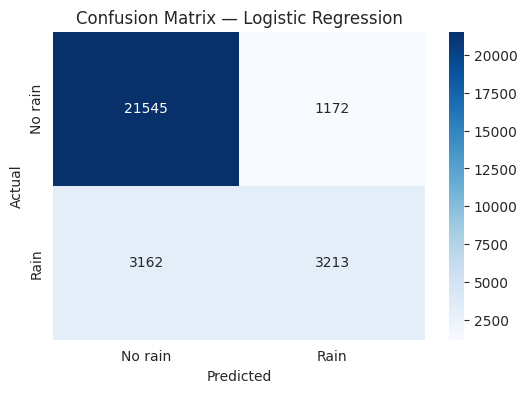

In [ ]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Logistic Regression', y_test, y_pred))
models['Logistic Regression'] = ('scaled', lr)
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression', labels=target_labels)
plt.show()


  Decision Tree
  Accuracy    : 0.8385
  Precision   : 0.6715
  Recall      : 0.5147
  F1 Score    : 0.5827


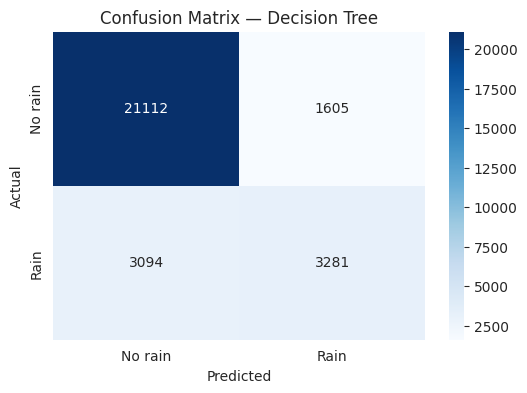

In [ ]:
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_confusion_matrix(y_test, y_pred, 'Decision Tree', labels=target_labels)
plt.show()


  Random Forest
  Accuracy    : 0.8598
  Precision   : 0.7785
  Recall      : 0.5034
  F1 Score    : 0.6114


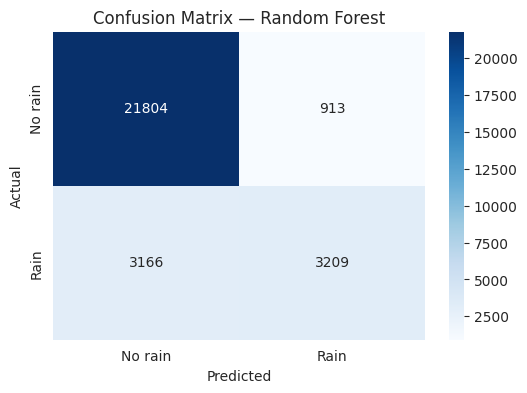

In [ ]:
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_confusion_matrix(y_test, y_pred, 'Random Forest', labels=target_labels)
plt.show()

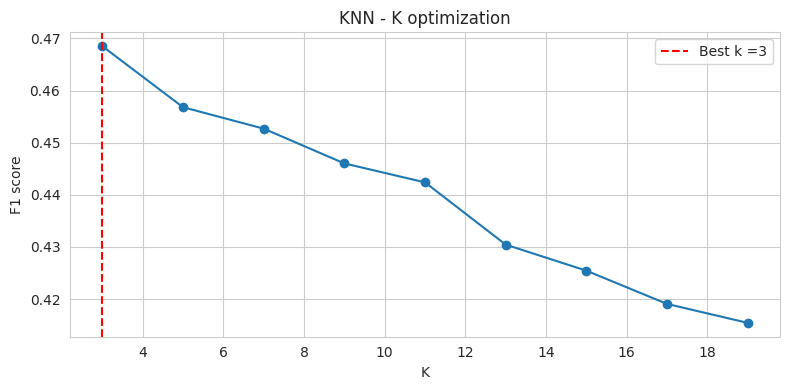


  K-Nearest Neighbors
  Accuracy    : 0.8086
  Precision   : 0.5984
  Recall      : 0.3849
  F1 Score    : 0.4685


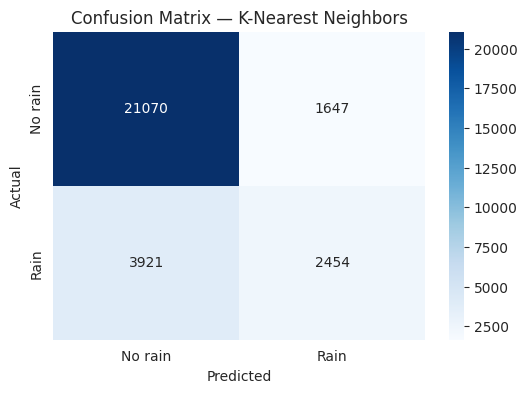

In [13]:
K_range = range(3, 21, 2)
K_scores =[]
knn_label = 'K-Nearest Neighbors'
for k in K_range:
  knn_t = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
  knn_t.fit(X_train_scaled, y_train)
  K_scores.append(f1_score(y_test, knn_t.predict(X_test_scaled), zero_division=0))
best_k = list(K_range)[int(np.argmax(K_scores))]
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), K_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k ={best_k}')
plt.xlabel('K'); plt.ylabel('F1 score'); plt.title('KNN - K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_confusion_matrix(y_test, y_pred, knn_label, labels=target_labels)
plt.show()


  SVM
  Accuracy    : 0.4926
  Precision   : 0.2280
  Recall      : 0.5512
  F1 Score    : 0.3225


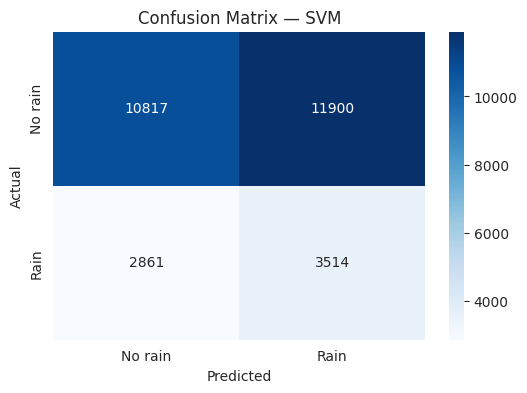

In [14]:
svm = SVC(random_state=42, probability=True, kernel='linear', max_iter=2000)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
results.append(evaluate_model('SVM', y_test, y_pred))
models['SVM'] = ('scaled', svm)
plot_confusion_matrix(y_test, y_pred, 'SVM', labels=target_labels)
plt.show()


  Gradient Boosting
  Accuracy    : 0.8545
  Precision   : 0.7506
  Recall      : 0.5032
  F1 Score    : 0.6025


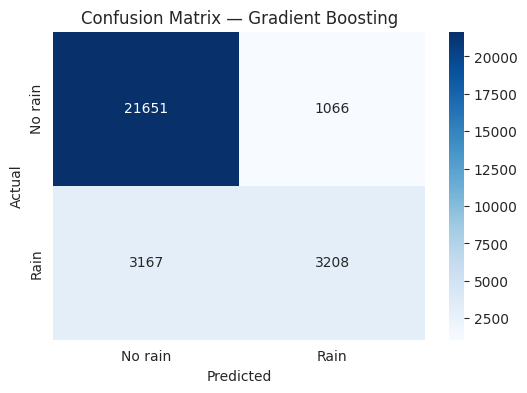

In [15]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_confusion_matrix(y_test, y_pred, 'Gradient Boosting', labels=target_labels)
plt.show()


  Naive Bayes
  Accuracy    : 0.6698
  Precision   : 0.3708
  Recall      : 0.7275
  F1 Score    : 0.4912


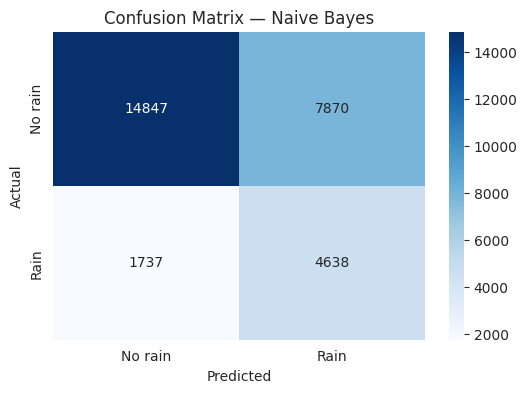

In [16]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)
y_pred = nb_clf.predict(X_test_scaled)
results.append(evaluate_model('Naive Bayes', y_test, y_pred))
models['Naive Bayes'] = ('scaled', nb_clf)
plot_confusion_matrix(y_test, y_pred, 'Naive Bayes', labels=target_labels)
plt.show()

#4. Feature Importance - Tree Models

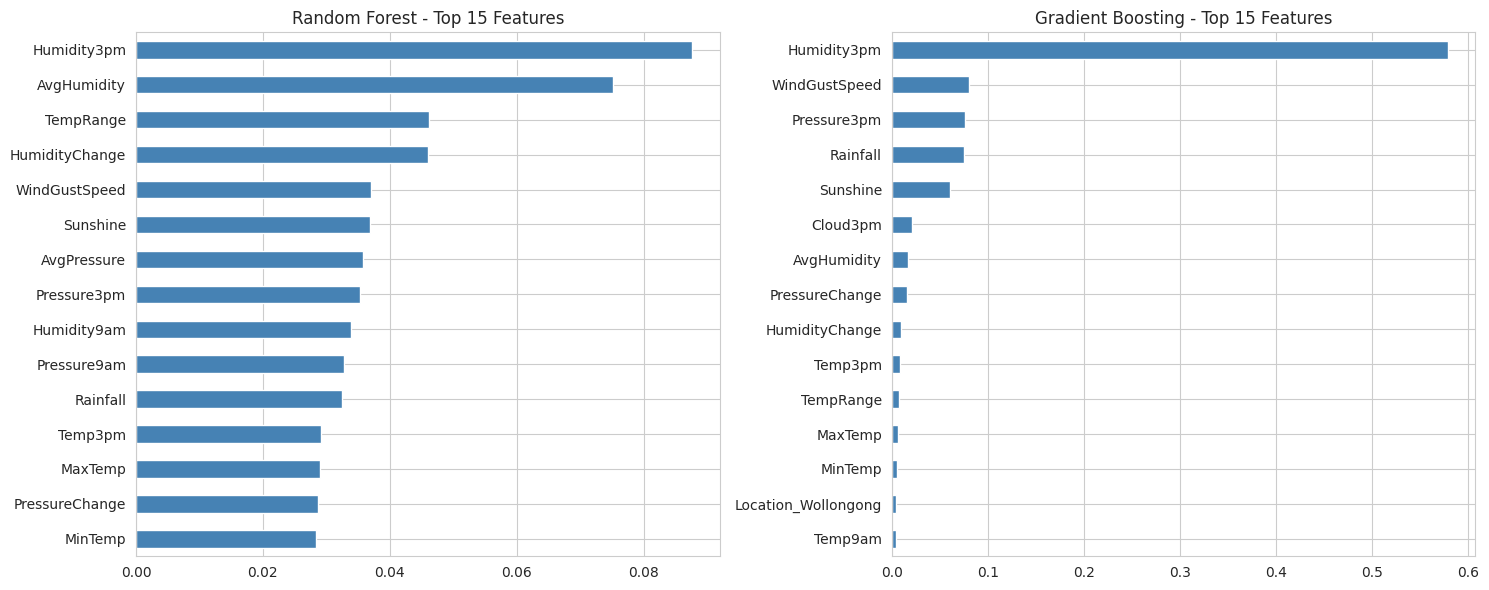

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
  importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
  importances.plot(kind='barh', ax=ax, color='steelblue')
  ax.set_title(f'{name} - Top 15 Features')
plt.tight_layout(); plt.show()

#5. Model Comparison

In [19]:
comparison = compare_models(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.859790,0.778506,0.503373,0.611413
1,Gradient Boosting,0.854496,0.750585,0.503216,0.602498
2,Logistic Regression,0.851024,0.732725,0.504000,0.597212
3,Decision Tree,0.838478,0.671510,0.514667,0.582719
4,Naive Bayes,0.669772,0.370803,0.727529,0.491236
5,K-Nearest Neighbors,0.808607,0.598391,0.384941,0.468499
6,K-Nearest Neighbors,0.808607,0.598391,0.384941,0.468499
7,SVM,0.492610,0.227975,0.551216,0.322548


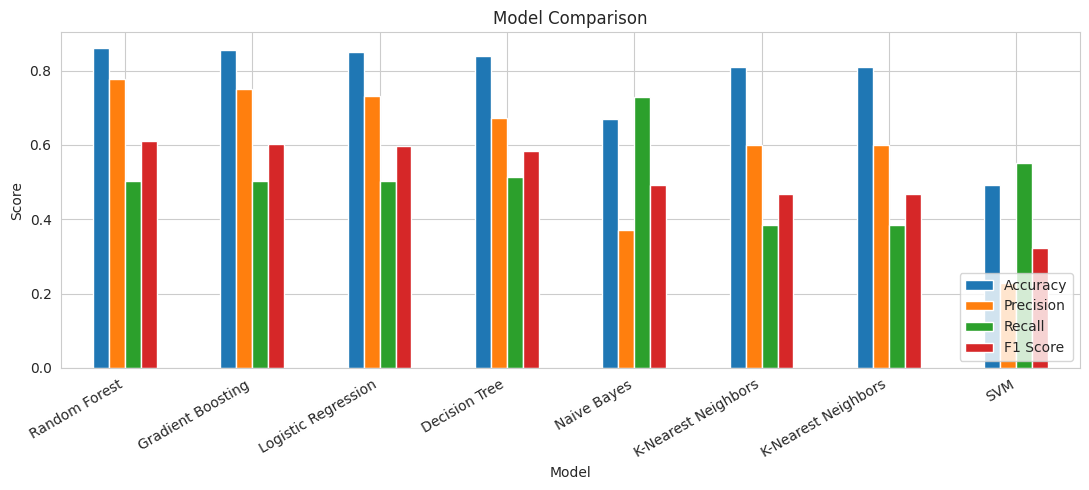

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison'); ax.set_ylabel('Score')
plt.xticks(rotation=30, ha='right'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

#6. 5-Fold Cross-Validation

In [22]:
cv_idx = np.random.RandomState(42).choice(len(X), size=min(len(X), 8000), replace=False)
X_cv, y_cv = X.iloc[cv_idx], y.iloc[cv_idx]
X_cv_scaled = scaler.fit_transform(X_cv)
print('CV sample size:', len(X_cv))

CV sample size: 8000


In [24]:
cv_scores = {}
for name, (kind, model) in models.items():
  if kind == 'scaled':
      scores = cross_val_score(model, X_cv_scaled, y_cv, cv=5, scoring='f1', n_jobs=-1)
  else:
      scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='f1', n_jobs=-1)
  cv_scores[name] = scores
  print(f'{name:.25s}  mean F1 = {scores.mean():.4f} (+/- {scores.std():.4f})')

Logistic Regression  mean F1 = 0.5952 (+/- 0.0113)
Decision Tree  mean F1 = 0.5252 (+/- 0.0108)
Random Forest  mean F1 = 0.5644 (+/- 0.0098)
K-Nearest Neighbors  mean F1 = 0.4045 (+/- 0.0197)
SVM  mean F1 = 0.3711 (+/- 0.0488)
Gradient Boosting  mean F1 = 0.5796 (+/- 0.0127)
Naive Bayes  mean F1 = 0.4839 (+/- 0.0136)


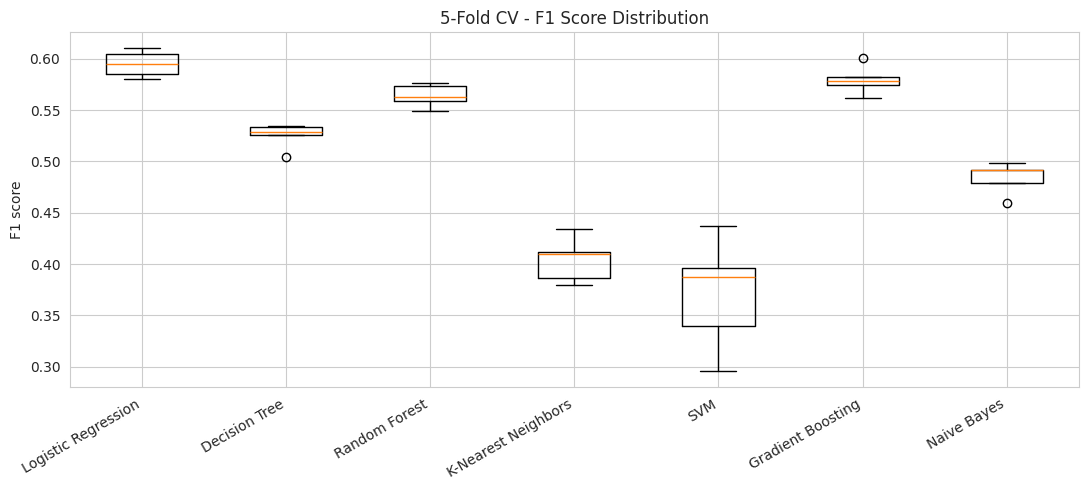

In [25]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('F1 score'); plt.title('5-Fold CV - F1 Score Distribution')
plt.tight_layout(); plt.show()

#7. ROC Curves

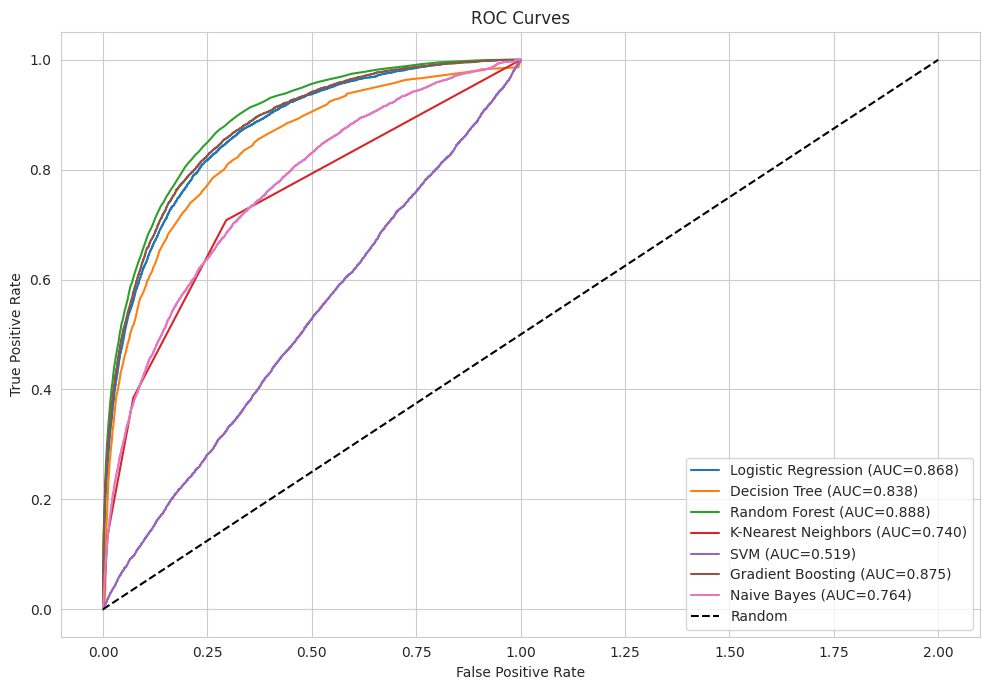

In [27]:
plt.figure(figsize=(10, 7))
for name, (kind, m) in models.items():
  xt = X_test_scaled if kind == 'scaled' else X_test
  if hasattr(m, 'predict_proba'):
      yp = m.predict_proba(xt)[:, 1]
  else:
      yp = m.decision_function(xt)
  fpr, tpr, _ = roc_curve(y_test, yp)
  plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 2], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

#8. Hyperparameter Tuning - Best Performer

In [28]:
best_model_name = comparison.iloc[0]['Model']
print('Best model by F1:', best_model_name)

Best model by F1: Random Forest


Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.5948

  Tuned Random Forest
  Accuracy    : 0.8594
  Precision   : 0.7745
  Recall      : 0.5054
  F1 Score    : 0.6117


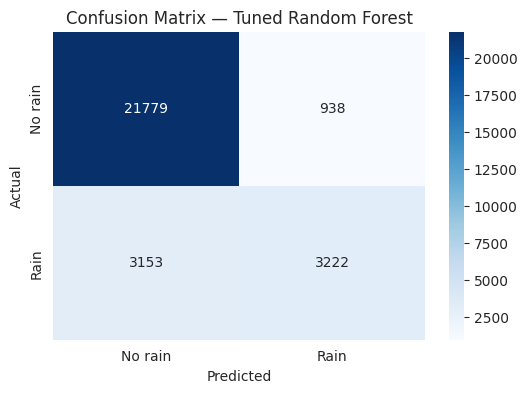

In [32]:
# Tuned Random Forest with reduced grid (Dataset is large)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5],
}
rf_t = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_t, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best parameters:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Tuned Random Forest', y_test, y_pred)
results.append(tuned_metrics)
plot_confusion_matrix(y_test, y_pred, 'Tuned Random Forest', labels=target_labels)
plt.show()


#9. Tuned Model - Feature Importance

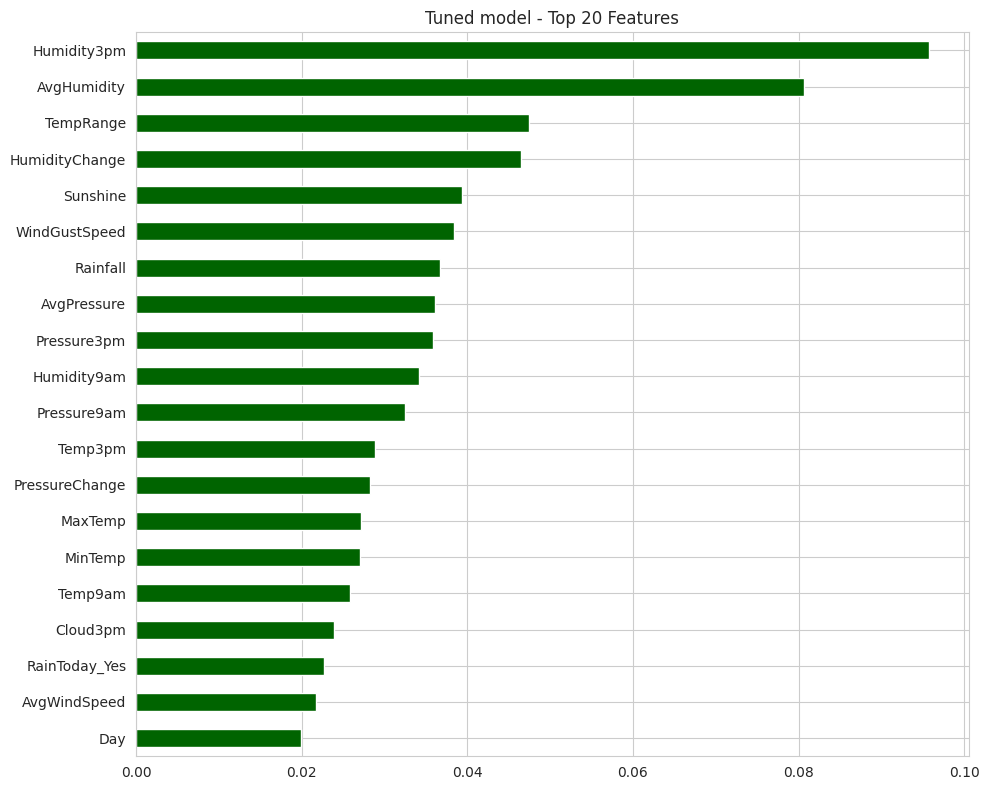

In [33]:
if hasattr(best, 'feature_importances_'):
  importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
  plt.figure(figsize=(10, 8))
  importances.plot(kind='barh', color='darkgreen')
  plt.title('Tuned model - Top 20 Features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
  importances = pd.Series(np.abs(best.coef_[0]), index=X.columns).sort_values(ascending=True).tail(20)
  plt.figure(figsize=(10, 8))
  importances.plot(kind='barh', color='darkgreen')
  plt.title('Tuned model - Top 20 | coefficients'); plt.tight_layout(); plt.show()

#10. Sample Prediction

In [35]:
sample = X_test.iloc[:5].copy()
if 'best' in dir() and hasattr(best, 'predict'):
  preds = best.predict(sample)
  out = pd.DataFrame({'Predicted': preds, 'Actual': y_test.iloc[:5].values})
  if hasattr(best, 'predict_proba'):
    out['Probability'] = best.predict_proba(sample)[:, 1].round(3)
  print(out)
  out

   Predicted  Actual  Probability
0          0       0        0.363
1          0       0        0.038
2          0       1        0.461
3          0       0        0.010
4          0       0        0.074


#11. Final Summary

In [36]:
final = compare_models(results)
final

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Random Forest,0.859377,0.774519,0.505412,0.611675
1,Random Forest,0.859790,0.778506,0.503373,0.611413
2,Gradient Boosting,0.854496,0.750585,0.503216,0.602498
3,Logistic Regression,0.851024,0.732725,0.504000,0.597212
4,Decision Tree,0.838478,0.671510,0.514667,0.582719
5,Naive Bayes,0.669772,0.370803,0.727529,0.491236
6,K-Nearest Neighbors,0.808607,0.598391,0.384941,0.468499
7,K-Nearest Neighbors,0.808607,0.598391,0.384941,0.468499
8,SVM,0.492610,0.227975,0.551216,0.322548


##Key Takeaways

**.** Rain prediction (Australia): binary classification on `RainTomorrow`

**.** 7 classifiers + 1 tuned variant evaluated on accuracy / precision / recall / F1.

**.** Tree-Bases models highlight the most predictive features.

**.** ROC curves show discrimibnative power across thresholds.

##Next Steps

**.** Try class-weight balancing or SMOTE for imbalance.

**.** Test gradient bosters (XGBoost, LightGBM).

**.** Add probability calibration if scores are used dwonstream.

**.** Domain-Specific features engineering may further improve results.